# Analyse Exploratoire des Données — Projet WADI
**Hackathon IA — Prévision du niveau du réservoir**

---
## Sommaire
1. [Importation des librairies et chargement des données](#1)
2. [Aperçu général du jeu de données](#2)
3. [Typage des variables](#3)
4. [Gestion des valeurs manquantes](#4)
5. [Gestion des doublons](#5)
6. [Analyse des variables cibles (LT)](#6)
7. [Statistiques descriptives globales](#7)
8. [Visualisation temporelle des variables clés](#8)
9. [Détection des outliers](#9)
10. [Matrices de corrélation](#10)
11. [Analyse en Composantes Principales (ACP)](#11)
12. [Sauvegarde du dataset nettoyé](#12)

---
> **Variable cible :** `1_LT_001_PV`, `2_LT_001_PV`, `2_LT_002_PV`, `3_LT_001_PV` — niveaux des réservoirs  
> **Fréquence d'échantillonnage :** 1 mesure / minute  
> **Durée :** 14 jours (~784 000 lignes, 130 colonnes)

<a id='1'></a>
## 1. Importation des librairies et chargement des données

In [7]:
# ── Librairies standard ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Machine Learning / Stats ─────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Paramètres d'affichage ───────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Librairies importées avec succès')

Librairies importées avec succès


In [85]:
# ── Chargement du fichier CSV ─────────────────────────────────────────────────
### Importation de la base de données
### On crée une fonction qui demande le chemin d'accès au données et les charge
def load_wadi_data():
    path = input("Veuillez entrer le chemin complet du fichier CSV : ")
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Base chargée : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
        return df
    else:
        print("Chemin invalide.")
        return None

df_raw = load_wadi_data()

# print(f' Fichier chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')

Veuillez entrer le chemin complet du fichier CSV :  E:\MASTER_STD\MASTER_1_STD\Hackaton\Actemium\Actemium\hackathon\WADI_14days_new.csv


Base chargée : 784571 lignes, 130 colonnes.


<a id='2'></a>
## 2. Aperçu général du jeu de données

In [155]:
# ── Premières lignes ──────────────────────────────────────────────────────────
df_raw[1439:3603]

# df_raw.duplicated().sum()

,Row,Date,Time,1_AIT_001_PV,1_AIT_002_PV,1_AIT_003_PV,1_AIT_004_PV,1_AIT_005_PV,1_FIT_001_PV,1_LS_001_AL,1_LS_002_AL,1_LT_001_PV,1_MV_001_STATUS,1_MV_002_STATUS,1_MV_003_STATUS,1_MV_004_STATUS,1_P_001_STATUS,1_P_002_STATUS,1_P_003_STATUS,1_P_004_STATUS,1_P_005_STATUS,1_P_006_STATUS,2_DPIT_001_PV,2_FIC_101_CO,2_FIC_101_PV,...,2A_AIT_002_PV,2A_AIT_003_PV,2A_AIT_004_PV,2B_AIT_001_PV,2B_AIT_002_PV,2B_AIT_003_PV,2B_AIT_004_PV,3_AIT_001_PV,3_AIT_002_PV,3_AIT_003_PV,3_AIT_004_PV,3_AIT_005_PV,3_FIT_001_PV,3_LS_001_AL,3_LT_001_PV,3_MV_001_STATUS,3_MV_002_STATUS,3_MV_003_STATUS,3_P_001_STATUS,3_P_002_STATUS,3_P_003_STATUS,3_P_004_STATUS,LEAK_DIFF_PRESSURE,PLANT_START_STOP_LOG,TOTAL_CONS_REQUIRED_FLOW
1439,1440,9/25/2017,23:59.0,172.4910,0.6675,11.7827,476.0980,0.2542,1.9368,0,0,44.8852,2,1,1,1,2,1,2,1,1,1,2498.3100,33.8562,0.1314,...,0.0000,8.5625,476.3570,0.2002,8.9434,8.6163,475.5970,0.0000,0.0000,1.2662,603.0180,0.3626,0.0012,1,64.3945,1,1,1,1,1,1,1,64.6485,1,0.6800
1440,1441,9/25/2017,24:00.0,172.4910,0.6675,11.7827,476.0980,0.2542,1.9368,0,0,44.8852,2,1,1,1,2,1,2,1,1,1,2498.3100,33.8562,0.1314,...,0.0000,8.5625,476.3570,0.2002,8.9434,8.6163,475.5970,0.0000,0.0000,1.2662,603.0180,0.3626,0.0012,1,64.3945,1,1,1,1,1,1,1,64.6485,1,0.6800
1441,1442,9/25/2017,24:01.0,172.4910,0.6675,11.7827,476.0980,0.2542,1.9368,0,0,44.8852,2,1,1,1,2,1,2,1,1,1,2498.3100,33.8562,0.1314,...,0.0000,8.5625,476.3090,0.2002,9.0030,8.6160,475.6900,0.0000,0.0000,1.2662,603.0180,0.3626,0.0012,1,64.3945,1,1,1,1,1,1,1,64.6485,1,0.6800
1442,1443,9/25/2017,24:02.0,172.4910,0.6675,11.7827,476.0980,0.2542,1.9368,0,0,44.8852,2,1,1,1,2,1,2,1,1,1,2498.3100,33.8562,0.1314,...,0.0000,8.5625,476.3090,0.2002,9.0030,8.6160,475.6900,0.0000,0.0000,1.2662,603.0180,0.3626,0.0012,1,64.3945,1,1,1,1,1,1,1,64.6485,1,0.6800
1443,1444,9/25/2017,24:03.0,172.4430,0.6255,11.7787,476.1150,0.2542,1.9343,0,0,44.8523,2,1,1,1,2,1,2,1,1,1,2498.1300,33.8644,0.1309,...,0.0000,8.5625,476.3090,0.2002,9.0030,8.6160,475.6900,0.0000,0.0000,1.2547,604.9420,0.3625,0.0013,1,64.3780,1,1,1,1,1,1,1,64.5797,1,0.6800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3598,3599,9/25/2017,59:58.0,169.5410,0.5835,11.6411,497.9150,0.2348,0.0011,0,0,62.2089,1,1,1,2,1,1,1,1,1,1,2492.9800,30.8770,0.1270,...,0.0000,8.5625,476.8670,0.1992,9.1176,8.6158,475.8810,0.0000,0.0000,1.4584,578.8570,0.3818,0.0012,1,64.4842,1,1,1,1,1,1,1,63.5548,1,0.6900
3599,3600,9/25/2017,59:59.0,169.5410,0.5835,11.6411,497.9150,0.2348,0.0011,0,0,62.2089,1,1,1,2,1,1,1,1,1,1,2492.9800,30.8770,0.1270,...,0.0000,8.5625,476.8670,0.1992,9.1176,8.6158,475.8810,0.0000,0.0000,1.4584,578.8570,0.3818,0.0012,1,64.4842,1,1,1,1,1,1,1,63.5548,1,0.6900
3600,3601,9/25/2017,00:00.0,169.5410,0.5835,11.6411,497.9150,0.2348,0.0011,0,0,62.2089,1,1,1,2,1,1,1,1,1,1,2492.9800,30.8770,0.1270,...,0.0000,8.5625,476.8670,0.1992,9.1176,8.6158,475.8810,0.0000,0.0000,1.4584,578.8570,0.3818,0.0012,1,64.4842,1,1,1,1,1,1,1,63.5548,1,0.6900
3601,3602,9/25/2017,00:01.0,169.5410,0.5835,11.6411,497.9150,0.2348,0.0011,0,0,62.2089,1,1,1,2,1,1,1,1,1,1,2492.9800,30.8770,0.1270,...,0.0000,8.5625,476.8670,0.1992,9.1176,8.6158,475.8810,0.0000,0.0000,1.4584,578.8570,0.3818,0.0012,1,64.4842,1,1,1,1,1,1,1,63.5548,1,0.6900


In [23]:
# ── Dernières lignes ──────────────────────────────────────────────────────────
df_raw.tail(3)

,Row,Date,Time,1_AIT_001_PV,1_AIT_002_PV,1_AIT_003_PV,1_AIT_004_PV,1_AIT_005_PV,1_FIT_001_PV,1_LS_001_AL,1_LS_002_AL,1_LT_001_PV,1_MV_001_STATUS,1_MV_002_STATUS,1_MV_003_STATUS,1_MV_004_STATUS,1_P_001_STATUS,1_P_002_STATUS,1_P_003_STATUS,1_P_004_STATUS,1_P_005_STATUS,1_P_006_STATUS,2_DPIT_001_PV,2_FIC_101_CO,2_FIC_101_PV,...,2A_AIT_002_PV,2A_AIT_003_PV,2A_AIT_004_PV,2B_AIT_001_PV,2B_AIT_002_PV,2B_AIT_003_PV,2B_AIT_004_PV,3_AIT_001_PV,3_AIT_002_PV,3_AIT_003_PV,3_AIT_004_PV,3_AIT_005_PV,3_FIT_001_PV,3_LS_001_AL,3_LT_001_PV,3_MV_001_STATUS,3_MV_002_STATUS,3_MV_003_STATUS,3_P_001_STATUS,3_P_002_STATUS,3_P_003_STATUS,3_P_004_STATUS,LEAK_DIFF_PRESSURE,PLANT_START_STOP_LOG,TOTAL_CONS_REQUIRED_FLOW
784568,1048569,10/7/17,16:08.0,175.8550,0.5895,11.8941,479.1910,0.3316,0.0011,0,0,48.1129,1,1,1,1,1,1,1,1,1,1,2570.7000,29.8682,0.1300,...,0.0000,8.6250,479.8170,0.1992,9.3748,8.6276,479.0770,0.0000,8279.1000,16.6601,229.3640,0.7624,0.6172,1,64.2154,1,1,1,1,1,1,1,60.6305,1,0.2500
784569,1048570,10/7/17,16:09.0,175.8960,0.6135,11.8913,479.2240,0.3316,0.0012,0,0,48.0348,1,1,1,1,1,1,1,1,1,1,2567.2600,29.9048,0.1279,...,0.0000,8.6250,479.8170,0.1992,9.3748,8.6276,479.0770,0.0000,8279.1000,36.5622,-1075.3800,0.7624,0.6172,1,64.2357,1,1,1,1,1,1,1,60.4477,1,0.2500
784570,1048571,10/7/17,16:10.0,175.8960,0.6135,11.8913,479.2240,0.3316,0.0012,0,0,48.0348,1,1,1,1,1,1,1,1,1,1,2567.2600,29.9048,0.1279,...,0.0000,8.6250,479.8170,0.1992,9.3748,8.6276,479.0770,0.0000,8279.1000,36.5622,-1075.3800,0.7624,0.6172,1,64.2357,1,1,1,1,1,1,1,60.4477,1,0.2500


In [40]:
# ── Informations générales (types, mémoire) ───────────────────────────────────
# df_raw.info(verbose=True, show_counts=True)

In [81]:
# ── Résumé des familles de variables présentes ────────────────────────────────
prefixes = ['AIT', 'FIT', 'LT', 'LS', 'MV', 'FIC', 'PIC', 'PIT', 'DPIT',
            'FQ', 'SV', 'P_', 'LEAK', 'PLANT', 'TOTAL']

summary_families = {}
for p in prefixes:
    cols = [c for c in df_raw.columns if p in c]
    summary_families[p] = len(cols)

print('Famille de capteurs / variables | Nombre de colonnes')
print('-' * 48)
for k, v in summary_families.items():
    print(f'  {k:<30} {v}')

Famille de capteurs / variables | Nombre de colonnes
------------------------------------------------
  AIT                            18
  FIT                            5
  LT                             4
  LS                             17
  MV                             20
  FIC                            18
  PIC                            3
  PIT                            4
  DPIT                           1
  FQ                             6
  SV                             6
  P_                             17
  LEAK                           1
  PLANT                          1
  TOTAL                          1


<a id='3'></a>
## 3. Typage des variables

Les règles de typage appliquées sont :
- **`STATUS`, `_AL`, `_AH`** : catégorielles (états ON/OFF, alarmes binaires)  
- **`AIT`, `FIT`, `LT`, `FIC`, `PIC`, `PIT`, `DPIT`, `FQ`** : numériques continues  
- **`Date`, `Time`** : combinées en un index datetime

In [133]:
# df = df_raw.copy()

# # ── 3.1  Création de l'index temporel ────────────────────────────────────────
# df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
#                                 format='%m/%d/%Y %M:%S.%f',
#                                 errors='coerce')
# # Si le format précédent échoue (variante sans millisecondes)
# mask_failed = df['Datetime'].isna()
# if mask_failed.sum() > 0:
#     df.loc[mask_failed, 'Datetime'] = pd.to_datetime(
#         df.loc[mask_failed, 'Date'] + ' ' + df.loc[mask_failed, 'Time'],
#         errors='coerce'
#     )

# df = df.set_index('Datetime').drop(columns=['Row', 'Date', 'Time'], errors='ignore')
# df = df.sort_index()

# print(f'Index temporel : de {df.index.min()} à {df.index.max()}')
# print(f'Durée totale   : {df.index.max() - df.index.min()}')

Index temporel : de 2017-09-25 00:00:00 à 2017-10-07 23:59:00
Durée totale   : 12 days 23:59:00


In [ ]:
# On identifie toutes les lignes qui ont des copies exactes ailleurs dans le dataset
# keep=False permet de garder TOUTES les occurrences (l'original + les copies)
all_duplicates = df_raw[df_raw.duplicated(subset=['Date', 'Time'] + [c for c in df_raw.columns if 'IT' in c], keep=False)]

# On trie par Date et Time pour les voir côte à côte
all_duplicates = all_duplicates.sort_values(by=['Date', 'Time'])

# Affichage des 20 premières lignes pour observation
print(f"Nombre total de lignes impliquées dans des doublons : {len(all_duplicates)}")
display(all_duplicates.head(20))

In [210]:
df = df_raw.copy()

# 1. On décompose le texte Time (ex: "59:58.0") en valeurs numériques
# On split sur ':' et on nettoie le '.0'
time_parts = df['Time'].astype(str).str.split(':')
m = time_parts.str[0].astype(int)
s = time_parts.str[1].str.split('.').str[0].astype(int)

# 2. On calcule l'heure réelle en se basant sur la progression des lignes
# On sait que Row 1 = 00:00:01. Donc (Row-1) / 3600 nous donne l'heure.
# On utilise // pour avoir le nombre entier d'heures.
h = (df['Row'].astype(int) - 1) // 3600
# Attention : si ton dataset ne commence pas à Row 1, ajuste le "- 1"

# 3. On crée la durée totale en secondes
# (Heures * 3600) + (Minutes * 60) + Secondes
total_seconds = (h * 3600) + (m * 60) + s

# 4. On assemble tout sur la date de départ
start_day = pd.to_datetime(df['Date'].iloc[0], format='mixed', dayfirst=False).normalize()
df['Datetime'] = start_day + pd.to_timedelta(total_seconds, unit='s')

# 5. On finalise l'index
df = df.set_index('Datetime').drop(columns=['Row', 'Date', 'Time'], errors='ignore')
df = df.sort_index()

print(f"Index final : {df.index.min()} à {df.index.max()}")

Index final : 2017-09-25 00:00:00 à 2017-10-07 03:16:10


In [167]:
df.tail(3)

,1_AIT_001_PV,1_AIT_002_PV,1_AIT_003_PV,1_AIT_004_PV,1_AIT_005_PV,1_FIT_001_PV,1_LS_001_AL,1_LS_002_AL,1_LT_001_PV,1_MV_001_STATUS,1_MV_002_STATUS,1_MV_003_STATUS,1_MV_004_STATUS,1_P_001_STATUS,1_P_002_STATUS,1_P_003_STATUS,1_P_004_STATUS,1_P_005_STATUS,1_P_006_STATUS,2_DPIT_001_PV,2_FIC_101_CO,2_FIC_101_PV,2_FIC_101_SP,2_FIC_201_CO,2_FIC_201_PV,...,2A_AIT_002_PV,2A_AIT_003_PV,2A_AIT_004_PV,2B_AIT_001_PV,2B_AIT_002_PV,2B_AIT_003_PV,2B_AIT_004_PV,3_AIT_001_PV,3_AIT_002_PV,3_AIT_003_PV,3_AIT_004_PV,3_AIT_005_PV,3_FIT_001_PV,3_LS_001_AL,3_LT_001_PV,3_MV_001_STATUS,3_MV_002_STATUS,3_MV_003_STATUS,3_P_001_STATUS,3_P_002_STATUS,3_P_003_STATUS,3_P_004_STATUS,LEAK_DIFF_PRESSURE,PLANT_START_STOP_LOG,TOTAL_CONS_REQUIRED_FLOW
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-10-07 03:16:08,175.8550,0.5895,11.8941,479.1910,0.3316,0.0011,0,0,48.1129,1,1,1,1,1,1,1,1,1,1,2570.7000,29.8682,0.1300,0.1300,100.0000,0.0518,...,0.0000,8.6250,479.8170,0.1992,9.3748,8.6276,479.0770,0.0000,8279.1000,16.6601,229.3640,0.7624,0.6172,1,64.2154,1,1,1,1,1,1,1,60.6305,1,0.2500
2017-10-07 03:16:09,175.8960,0.6135,11.8913,479.2240,0.3316,0.0012,0,0,48.0348,1,1,1,1,1,1,1,1,1,1,2567.2600,29.9048,0.1279,0.1300,100.0000,0.0518,...,0.0000,8.6250,479.8170,0.1992,9.3748,8.6276,479.0770,0.0000,8279.1000,36.5622,-1075.3800,0.7624,0.6172,1,64.2357,1,1,1,1,1,1,1,60.4477,1,0.2500
2017-10-07 03:16:10,175.8960,0.6135,11.8913,479.2240,0.3316,0.0012,0,0,48.0348,1,1,1,1,1,1,1,1,1,1,2567.2600,29.9048,0.1279,0.1300,100.0000,0.0518,...,0.0000,8.6250,479.8170,0.1992,9.3748,8.6276,479.0770,0.0000,8279.1000,36.5622,-1075.3800,0.7624,0.6172,1,64.2357,1,1,1,1,1,1,1,60.4477,1,0.2500


In [211]:
# ── 3.2  Conversion des colonnes catégorielles ────────────────────────────────
cat_keywords = ['STATUS', '_AL', '_AH', 'PLANT_START_STOP_LOG']
cat_cols = [c for c in df.columns
            if any(kw in c for kw in cat_keywords)]

for col in cat_cols:
    df[col] = pd.Categorical(df[col])

print(f'Colonnes converties en catégorielles : {len(cat_cols)}')
print(cat_cols)

Colonnes converties en catégorielles : 58
['1_LS_001_AL', '1_LS_002_AL', '1_MV_001_STATUS', '1_MV_002_STATUS', '1_MV_003_STATUS', '1_MV_004_STATUS', '1_P_001_STATUS', '1_P_002_STATUS', '1_P_003_STATUS', '1_P_004_STATUS', '1_P_005_STATUS', '1_P_006_STATUS', '2_LS_001_AL', '2_LS_002_AL', '2_LS_101_AH', '2_LS_101_AL', '2_LS_201_AH', '2_LS_201_AL', '2_LS_301_AH', '2_LS_301_AL', '2_LS_401_AH', '2_LS_401_AL', '2_LS_501_AH', '2_LS_501_AL', '2_LS_601_AH', '2_LS_601_AL', '2_MV_001_STATUS', '2_MV_002_STATUS', '2_MV_003_STATUS', '2_MV_004_STATUS', '2_MV_005_STATUS', '2_MV_006_STATUS', '2_MV_009_STATUS', '2_MV_101_STATUS', '2_MV_201_STATUS', '2_MV_301_STATUS', '2_MV_401_STATUS', '2_MV_501_STATUS', '2_MV_601_STATUS', '2_P_001_STATUS', '2_P_002_STATUS', '2_P_003_STATUS', '2_P_004_STATUS', '2_SV_101_STATUS', '2_SV_201_STATUS', '2_SV_301_STATUS', '2_SV_401_STATUS', '2_SV_501_STATUS', '2_SV_601_STATUS', '3_LS_001_AL', '3_MV_001_STATUS', '3_MV_002_STATUS', '3_MV_003_STATUS', '3_P_001_STATUS', '3_P_002_S

In [214]:
# ── 3.3  Conversion numérique (au cas où certaines colonnes seraient en object) ─
num_keywords = ['AIT', 'FIT', 'LT', 'FIC', 'PIC', 'PIT', 'DPIT', 'FQ',
                'SPEED', 'LEAK', 'TOTAL', 'FLOW']
num_cols = [c for c in df.columns
            if any(kw in c for kw in num_keywords) and c not in cat_cols]

for col in num_cols:
    if df[col].dtype == object:
        # Cas virgule comme séparateur décimal (ex: "504,645" → "504.645")
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False),
                                errors='coerce')

print(f'\nAperçu des types après conversion :')
print(df.dtypes.value_counts())


Aperçu des types après conversion :
float64     67
category    23
category    12
category    10
category     4
category     4
category     3
category     2
int64        2
Name: count, dtype: int64


<a id='4'></a>
## 4. Gestion des valeurs manquantes

In [216]:
# ── 4.1  Vue d'ensemble des valeurs manquantes ────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Nb manquants': missing,
    '% manquants': missing_pct
}).query('`Nb manquants` > 0').sort_values('% manquants', ascending=False)

print(f'Colonnes avec au moins 1 valeur manquante : {len(missing_report)}')
missing_report

Colonnes avec au moins 1 valeur manquante : 8


,Nb manquants,% manquants
2_LS_001_AL,784571,100.0000
2_LS_002_AL,784571,100.0000
2_P_001_STATUS,784571,100.0000
2_P_002_STATUS,784571,100.0000
1_AIT_002_PV,12,0.0000
1_AIT_004_PV,6,0.0000
2B_AIT_004_PV,10,0.0000
3_AIT_004_PV,6,0.0000


In [52]:
# # ── 4.2  Visualisation heatmap des manquants ──────────────────────────────────
# # On prend un échantillon de 5000 lignes pour ne pas saturer la mémoire
# sample_idx = np.linspace(0, len(df)-1, 5000, dtype=int)
# df_sample = df.iloc[sample_idx]

# plt.figure(figsize=(18, 5))
# sns.heatmap(df_sample.isnull().T,
#             cbar=False, yticklabels=False,
#             cmap='YlOrRd', xticklabels=False)
# plt.title('Carte des valeurs manquantes (échantillon 5 000 lignes × toutes colonnes)', fontsize=12)
# plt.xlabel('Temps (observations)')
# plt.tight_layout()
# plt.show()

In [218]:
# ── 4.3  Suppression des colonnes totalement vides ────────────────────────────
cols_vides = df.columns[df.isnull().all()].tolist()
print(f'Colonnes totalement vides ({len(cols_vides)}) :', cols_vides)

df = df.drop(columns=cols_vides)
print(f'\nDimensions après suppression des colonnes vides : {df.shape}')

Colonnes totalement vides (4) : ['2_LS_001_AL', '2_LS_002_AL', '2_P_001_STATUS', '2_P_002_STATUS']

Dimensions après suppression des colonnes vides : (784571, 123)


In [178]:
# df[1439:3603]

In [220]:
# ── 4.4  Suppression des colonnes à variance nulle (valeur constante) ─────────
numeric_cols_now = df.select_dtypes(include='number').columns
cols_figees = [c for c in numeric_cols_now if df[c].nunique(dropna=True) <= 1]

print(f'Colonnes à valeur constante ({len(cols_figees)}) :', cols_figees)

df = df.drop(columns=cols_figees)
print(f'\nDimensions après suppression colonnes figées : {df.shape}')

Colonnes à valeur constante (2) : ['2_MCV_007_CO', '2_PIC_003_SP']

Dimensions après suppression colonnes figées : (784571, 121)


In [222]:
# ── 4.5  Traitement des valeurs manquantes restantes ──────────────────────────
# Stratégie :
#   - Variables numériques continues → interpolation linéaire (séries temporelles)
#   - Variables catégorielles         → forward-fill (on conserve le dernier état connu)

# Colonnes numériques restantes
num_remaining = df.select_dtypes(include='number').columns.tolist()

# Colonnes catégorielles restantes
cat_remaining = df.select_dtypes(include='category').columns.tolist()

# Interpolation linéaire — limitée à 5 points consécutifs pour éviter d'inventer des données
df[num_remaining] = df[num_remaining].interpolate(method='linear', limit=5,
                                                   limit_direction='forward',
                                                   axis=0)

# Forward-fill pour les catégorielles
df[cat_remaining] = df[cat_remaining].ffill()

# Résumé après traitement
remaining_na = df.isnull().sum().sum()
print(f'Valeurs manquantes restantes après traitement : {remaining_na:,}')
print('(Les quelques NA restants correspondent à des lacunes > 5 min consécutives — conservées volontairement)')

Valeurs manquantes restantes après traitement : 9
(Les quelques NA restants correspondent à des lacunes > 5 min consécutives — conservées volontairement)


In [186]:
# df.info(verbose=True, show_counts=True)
df.index.duplicated().sum()

0

<a id='5'></a>
## 5. Gestion des doublons

In [67]:
# ── 5.1  Doublons sur l'index temporel ───────────────────────────────────────
nb_doublons_idx = df.index.duplicated().sum()
print(f'Timestamps dupliqués : {nb_doublons_idx}')

# ── 5.2  Lignes 100% identiques ───────────────────────────────────────────────
nb_doublons_purs = df.duplicated().sum()
print(f'Lignes 100% identiques : {nb_doublons_purs}')

# ── 5.3  Suppression si nécessaire ────────────────────────────────────────────
if nb_doublons_idx > 0:
    df = df[~df.index.duplicated(keep='first')]
    print(f'→ Doublons d\'index supprimés. Nouvelle taille : {df.shape}')

if nb_doublons_purs > 0:
    df = df[~df.duplicated()]
    print(f'→ Lignes dupliquées supprimées. Nouvelle taille : {df.shape}')

Timestamps dupliqués : 757930
Lignes 100% identiques : 580452
→ Doublons d'index supprimés. Nouvelle taille : (26641, 121)
→ Lignes dupliquées supprimées. Nouvelle taille : (23828, 121)


In [208]:
# # --- 5.1 Suppression des lignes 100% identiques ---
# # On le fait avant de toucher à l'index pour être précis
# avant = len(df)
# df = df.drop_duplicates()
# apres = len(df)
# print(f"Lignes 100% identiques supprimées : {avant - apres}")

# # --- 5.2 Gestion des timestamps dupliqués ---
# # Ici, on vérifie s'il reste des index identiques mais avec des données différentes
# if df.index.duplicated().any():
#     nb_doublons_idx = df.index.duplicated().sum()
#     print(f"Timestamps dupliqués restants (données divergentes) : {nb_doublons_idx}")
    
#     # On garde la première occurrence
#     df = df[~df.index.duplicated(keep='first')]
#     print(f"→ Index dupliqués nettoyés. Taille finale : {df.shape}")
# else:
#     print("Aucun doublon d'index détecté.")

Lignes 100% identiques supprimées : 580477
Aucun doublon d'index détecté.


<a id='6'></a>
## 6. Analyse des variables cibles (LT — niveaux des réservoirs)

Quatre colonnes LT sont présentes : `1_LT_001_PV`, `2_LT_001_PV`, `2_LT_002_PV`, `3_LT_001_PV`.  
La cible principale du forecasting est `3_LT_001_PV` (réservoir principal — zone 3).

In [224]:
LT_COLS = [c for c in df.columns if 'LT' in c and 'PV' in c]
TARGET = '3_LT_001_PV'   # variable cible principale

print('Colonnes LT identifiées :', LT_COLS)
print()
print(df[LT_COLS].describe())

Colonnes LT identifiées : ['1_LT_001_PV', '2_LT_001_PV', '2_LT_002_PV', '3_LT_001_PV']

       1_LT_001_PV  2_LT_001_PV  2_LT_002_PV  3_LT_001_PV
count  784571.0000  784571.0000  784571.0000  784571.0000
mean       56.3723      69.7735      75.4087      65.1680
std         8.8453       0.6482       3.4695       1.2200
min        38.8118      68.5104      65.6986      63.9590
25%        48.8368      69.2553      72.3303      64.3024
50%        57.2982      69.7136      75.5968      64.4502
75%        62.6110      70.2298      78.1341      66.0118
max        71.6190      71.5530      82.9788      69.1678


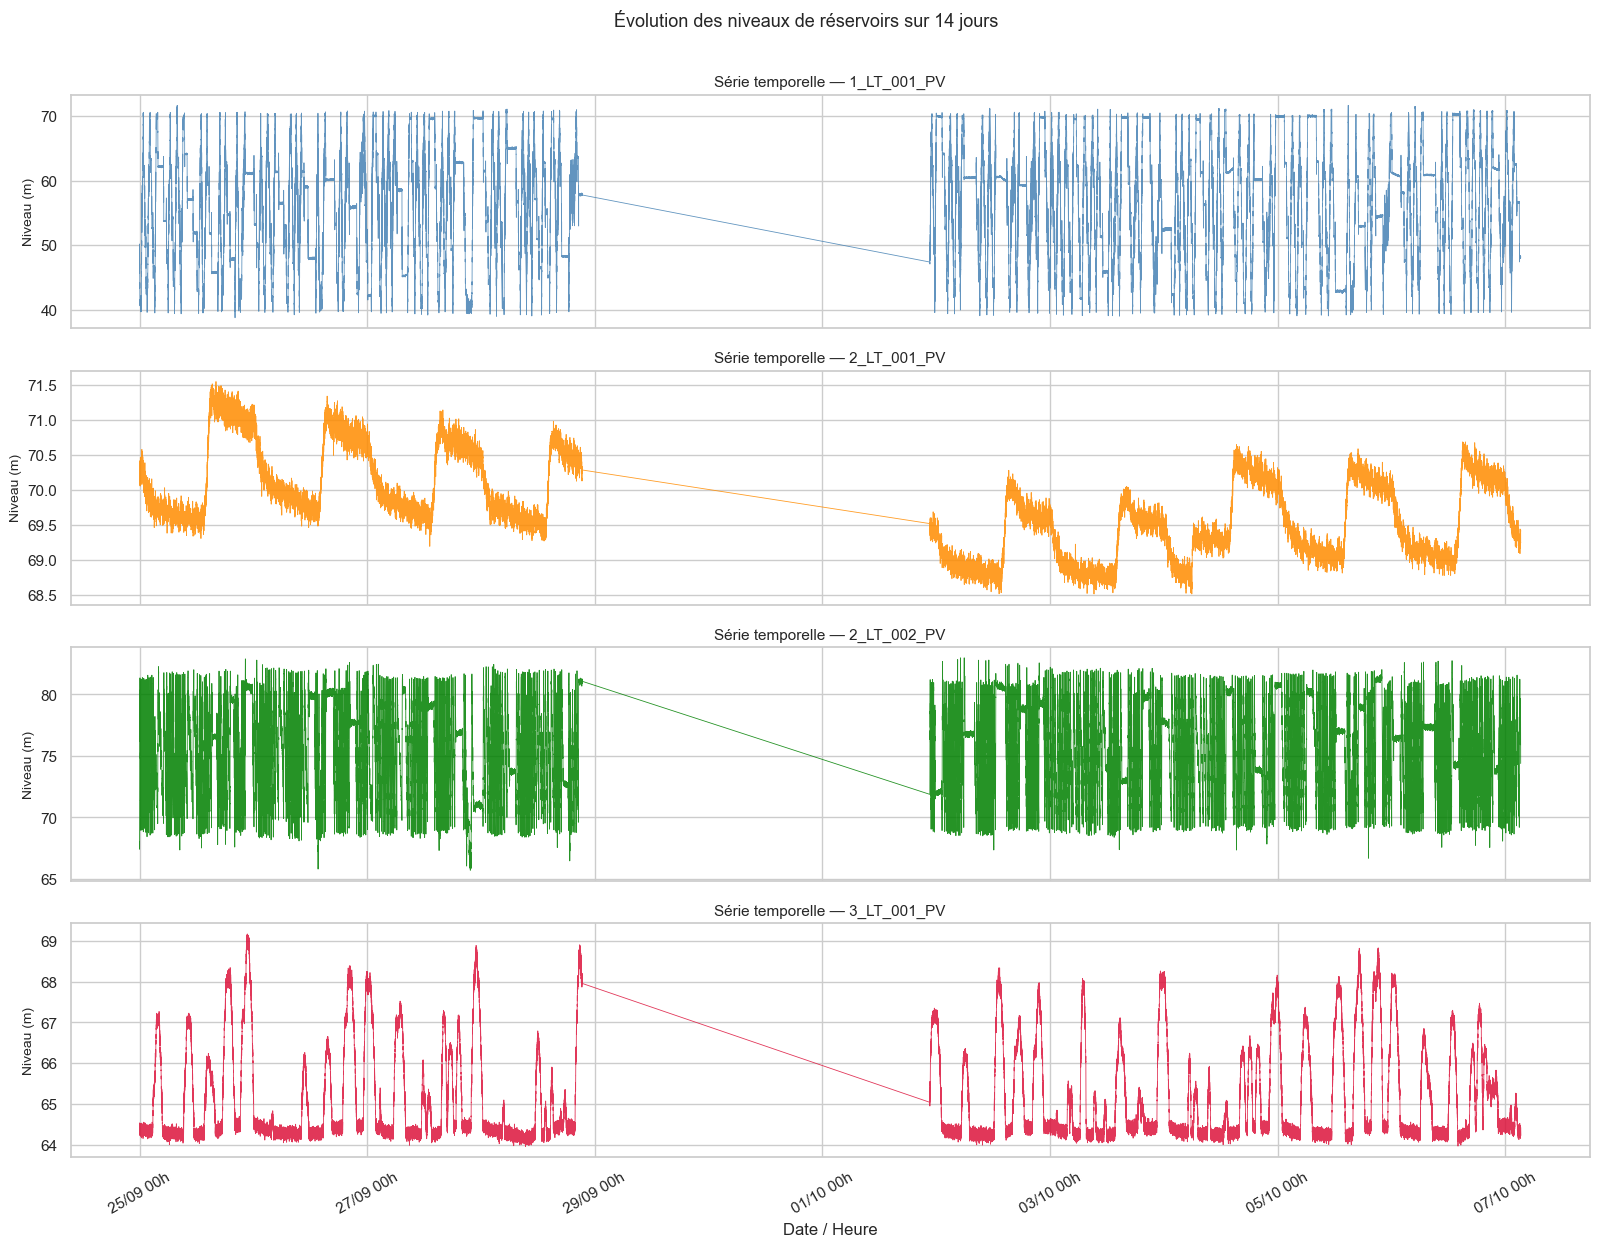

In [226]:
# ── 6.1  Séries temporelles des 4 variables LT ───────────────────────────────
fig, axes = plt.subplots(len(LT_COLS), 1, figsize=(16, 3 * len(LT_COLS)), sharex=True)

colors = ['steelblue', 'darkorange', 'green', 'crimson']
for ax, col, color in zip(axes, LT_COLS, colors):
    ax.plot(df.index, df[col], color=color, linewidth=0.6, alpha=0.85)
    ax.set_ylabel('Niveau (m)', fontsize=10)
    ax.set_title(f'Série temporelle — {col}', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

plt.xlabel('Date / Heure')
plt.suptitle('Évolution des niveaux de réservoirs sur 14 jours', fontsize=13, y=1.01)
plt.tight_layout()
plt.xticks(rotation=30)
plt.show()

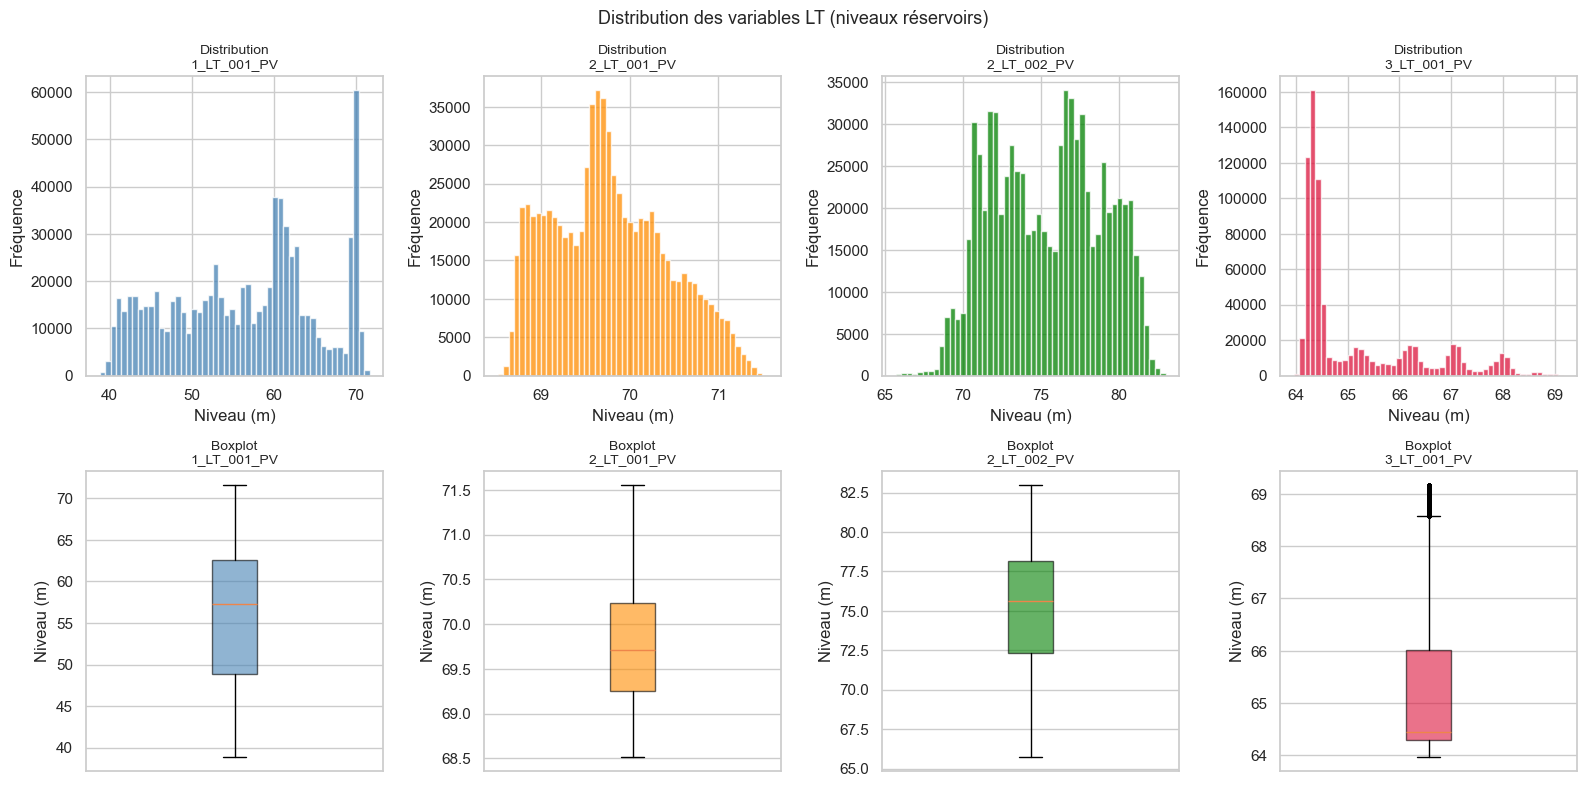

In [228]:
# ── 6.2  Distribution des variables LT (histogramme + boxplot) ───────────────
fig, axes = plt.subplots(2, len(LT_COLS), figsize=(16, 8))

for i, (col, color) in enumerate(zip(LT_COLS, colors)):
    # Histogramme
    axes[0, i].hist(df[col].dropna(), bins=50, color=color, alpha=0.75, edgecolor='white')
    axes[0, i].set_title(f'Distribution\n{col}', fontsize=10)
    axes[0, i].set_xlabel('Niveau (m)')
    axes[0, i].set_ylabel('Fréquence')

    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       flierprops=dict(marker='o', color='red', markersize=2))
    axes[1, i].set_title(f'Boxplot\n{col}', fontsize=10)
    axes[1, i].set_ylabel('Niveau (m)')
    axes[1, i].set_xticks([])

plt.suptitle('Distribution des variables LT (niveaux réservoirs)', fontsize=13)
plt.tight_layout()
plt.show()

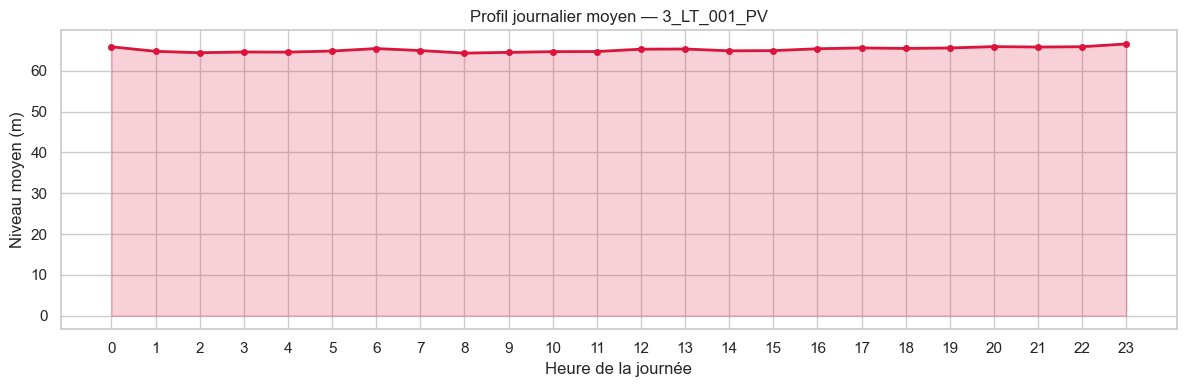

In [230]:
# ── 6.3  Zoom sur la cible principale : analyse journalière ──────────────────
df['hour'] = df.index.hour
df['day']  = df.index.date

# Niveau moyen par heure (profil journalier moyen)
hourly_profile = df.groupby('hour')[TARGET].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly_profile.index, hourly_profile.values,
         color='crimson', linewidth=2, marker='o', markersize=4)
plt.fill_between(hourly_profile.index, hourly_profile.values, alpha=0.2, color='crimson')
plt.xlabel('Heure de la journée')
plt.ylabel('Niveau moyen (m)')
plt.title(f'Profil journalier moyen — {TARGET}', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Statistiques descriptives globales

In [234]:
# ── Statistiques sur les variables numériques uniquement ─────────────────────
desc = df.select_dtypes(include='number').describe().T
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(4)  # coefficient de variation
desc.sort_values('cv', ascending=False, inplace=True)

print('Statistiques descriptives (triées par coefficient de variation décroissant) :')
desc.head(5)

Statistiques descriptives (triées par coefficient de variation décroissant) :


,count,mean,std,min,25%,50%,75%,max,cv
2A_AIT_002_PV,784571.0000,0.0016,0.0509,0.0000,0.0000,0.0000,0.0000,7.9004,32.3219
3_AIT_001_PV,784571.0000,0.0043,0.0255,0.0000,0.0000,0.0000,0.0000,0.1647,5.9638
2_FIT_003_PV,784571.0000,0.2072,0.5334,0.0000,0.0000,0.0000,0.0000,5.0883,2.5739
2_P_003_SPEED,784571.0000,3.4124,8.0757,-0.0951,-0.0141,-0.0124,-0.0111,41.6850,2.3666
2_PIC_003_PV,784571.0000,0.2166,0.4239,0.0112,0.0241,0.0277,0.0423,3.7671,1.9570


In [238]:
# ── Fréquences des variables catégorielles ────────────────────────────────────
# print('Fréquences des variables catégorielles (STATUS & alarmes) :\n')
# for col in df.select_dtypes(include='category').columns:
#     print(f'  {col}:')
#     print(df[col].value_counts().to_string())
#     print()

<a id='8'></a>
## 8. Visualisation temporelle des variables clés

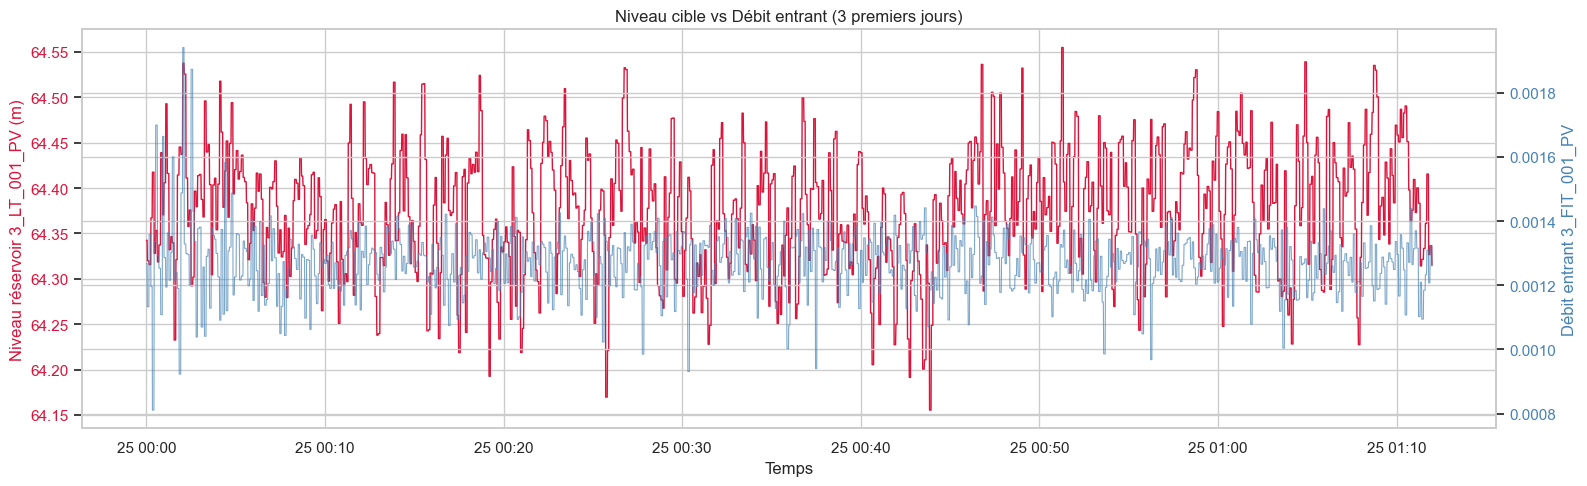

In [240]:
# ── 8.1  Débit entrant vs niveau cible ───────────────────────────────────────
# On prend un sous-ensemble de 3 jours pour la lisibilité
subset = df.iloc[:3*24*60]   # 3 premiers jours (1 mesure/min)

fig, ax1 = plt.subplots(figsize=(16, 5))

color1, color2 = 'steelblue', 'crimson'
ax1.set_xlabel('Temps')
ax1.set_ylabel(f'Niveau réservoir {TARGET} (m)', color=color2)
ax1.plot(subset.index, subset[TARGET], color=color2, linewidth=1, label=TARGET)
ax1.tick_params(axis='y', labelcolor=color2)

if '3_FIT_001_PV' in df.columns:
    ax2 = ax1.twinx()
    ax2.set_ylabel('Débit entrant 3_FIT_001_PV', color=color1)
    ax2.plot(subset.index, subset['3_FIT_001_PV'], color=color1, linewidth=0.8, alpha=0.7)
    ax2.tick_params(axis='y', labelcolor=color1)

plt.title('Niveau cible vs Débit entrant (3 premiers jours)', fontsize=12)
plt.tight_layout()
plt.show()

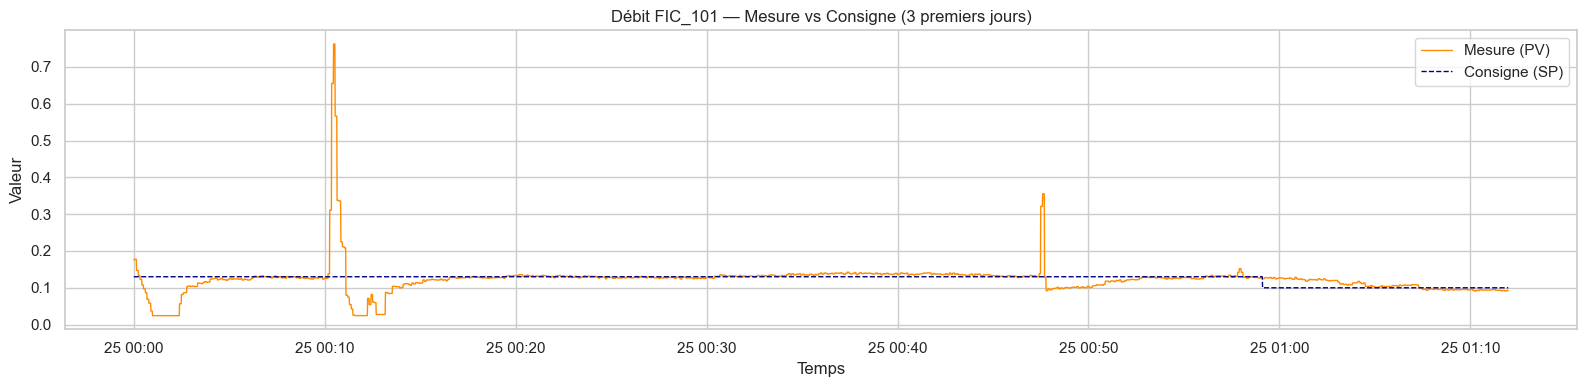

In [242]:
# ── 8.2  Débit FIC_101 : Mesure (PV) vs Consigne (SP) ────────────────────────
if '2_FIC_101_PV' in df.columns and '2_FIC_101_SP' in df.columns:
    plt.figure(figsize=(16, 4))
    plt.plot(subset.index, subset['2_FIC_101_PV'],
             label='Mesure (PV)', color='darkorange', linewidth=1)
    plt.plot(subset.index, subset['2_FIC_101_SP'],
             label='Consigne (SP)', color='navy', linestyle='--', linewidth=1)
    plt.xlabel('Temps')
    plt.ylabel('Valeur')
    plt.title('Débit FIC_101 — Mesure vs Consigne (3 premiers jours)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

<a id='9'></a>
## 9. Détection des outliers

Méthode utilisée : règle de Tukey (IQR × 1.5).  
**Important :** dans un contexte industriel, les valeurs extrêmes peuvent représenter des événements physiques réels (activation de pompe, anomalie). On les *détecte* mais on ne les supprime pas systématiquement.

In [250]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Retourne un masque booléen True là où la valeur est un outlier (IQR)."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)


# ── Rapport outliers sur toutes les variables numériques ─────────────────────
num_cols_clean = df.select_dtypes(include='number').columns.drop(['hour'], errors='ignore')
outlier_report = pd.DataFrame({
    'nb_outliers': [detect_outliers_iqr(df[c]).sum() for c in num_cols_clean],
    'pct_outliers': [(detect_outliers_iqr(df[c]).sum() / len(df) * 100).round(3)
                     for c in num_cols_clean]
}, index=num_cols_clean).sort_values('pct_outliers', ascending=False)

print('Top 20 colonnes avec le plus d\'outliers (méthode IQR) :')
outlier_report.head(5)

Top 20 colonnes avec le plus d'outliers (méthode IQR) :


,nb_outliers,pct_outliers
2_FIT_001_PV,190228,24.2460
3_AIT_002_PV,179875,22.9270
3_FIT_001_PV,165392,21.0810
2_PIC_003_CO,148348,18.9080
2_PIC_003_PV,144116,18.3690


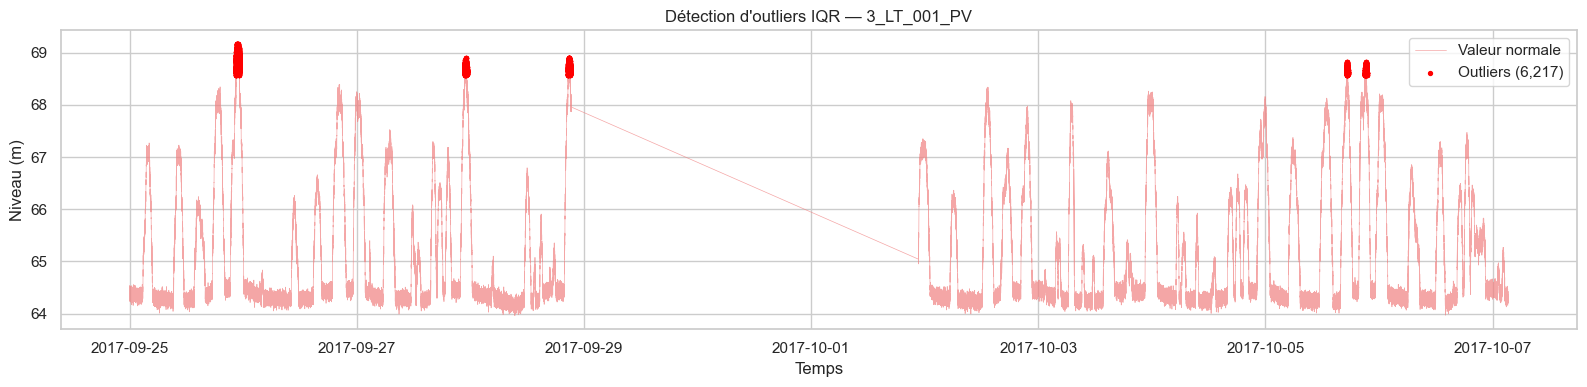

In [252]:
# ── Visualisation des outliers sur la variable cible ─────────────────────────
mask_outliers = detect_outliers_iqr(df[TARGET])

plt.figure(figsize=(16, 4))
plt.plot(df.index, df[TARGET], color='lightcoral', linewidth=0.5, label='Valeur normale', alpha=0.7)
plt.scatter(df.index[mask_outliers], df[TARGET][mask_outliers],
            color='red', s=8, label=f'Outliers ({mask_outliers.sum():,})', zorder=5)
plt.xlabel('Temps')
plt.ylabel('Niveau (m)')
plt.title(f'Détection d\'outliers IQR — {TARGET}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Matrices de corrélation

Vu le nombre élevé de variables (>100), on analyse la corrélation par groupes thématiques.

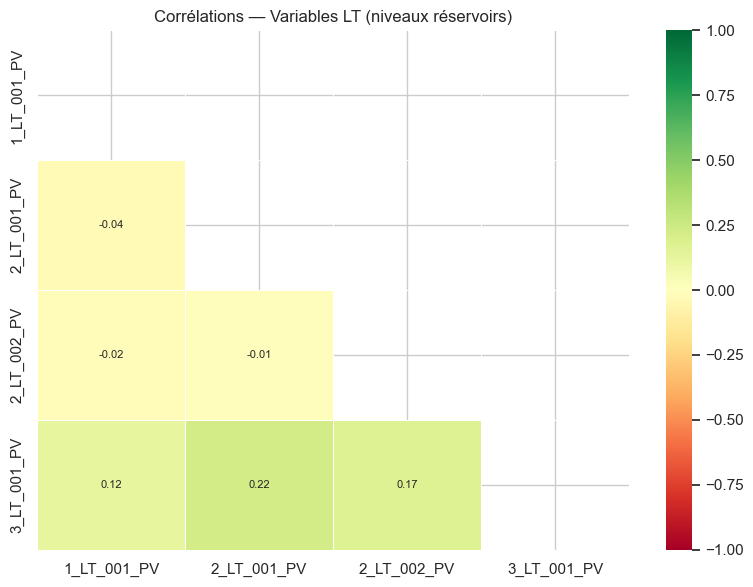

In [254]:
def plot_corr_matrix(df: pd.DataFrame, keyword: str, title: str, figsize=(12, 10)):
    """Trace une heatmap de corrélation pour les colonnes contenant `keyword`."""
    cols = [c for c in df.select_dtypes(include='number').columns if keyword in c]
    if len(cols) < 2:
        print(f'Pas assez de colonnes avec le mot-clé "{keyword}"')
        return
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # triangle supérieur masqué
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Corrélation des variables LT (niveaux) ────────────────────────────────────
plot_corr_matrix(df, 'LT', 'Corrélations — Variables LT (niveaux réservoirs)', figsize=(8, 6))

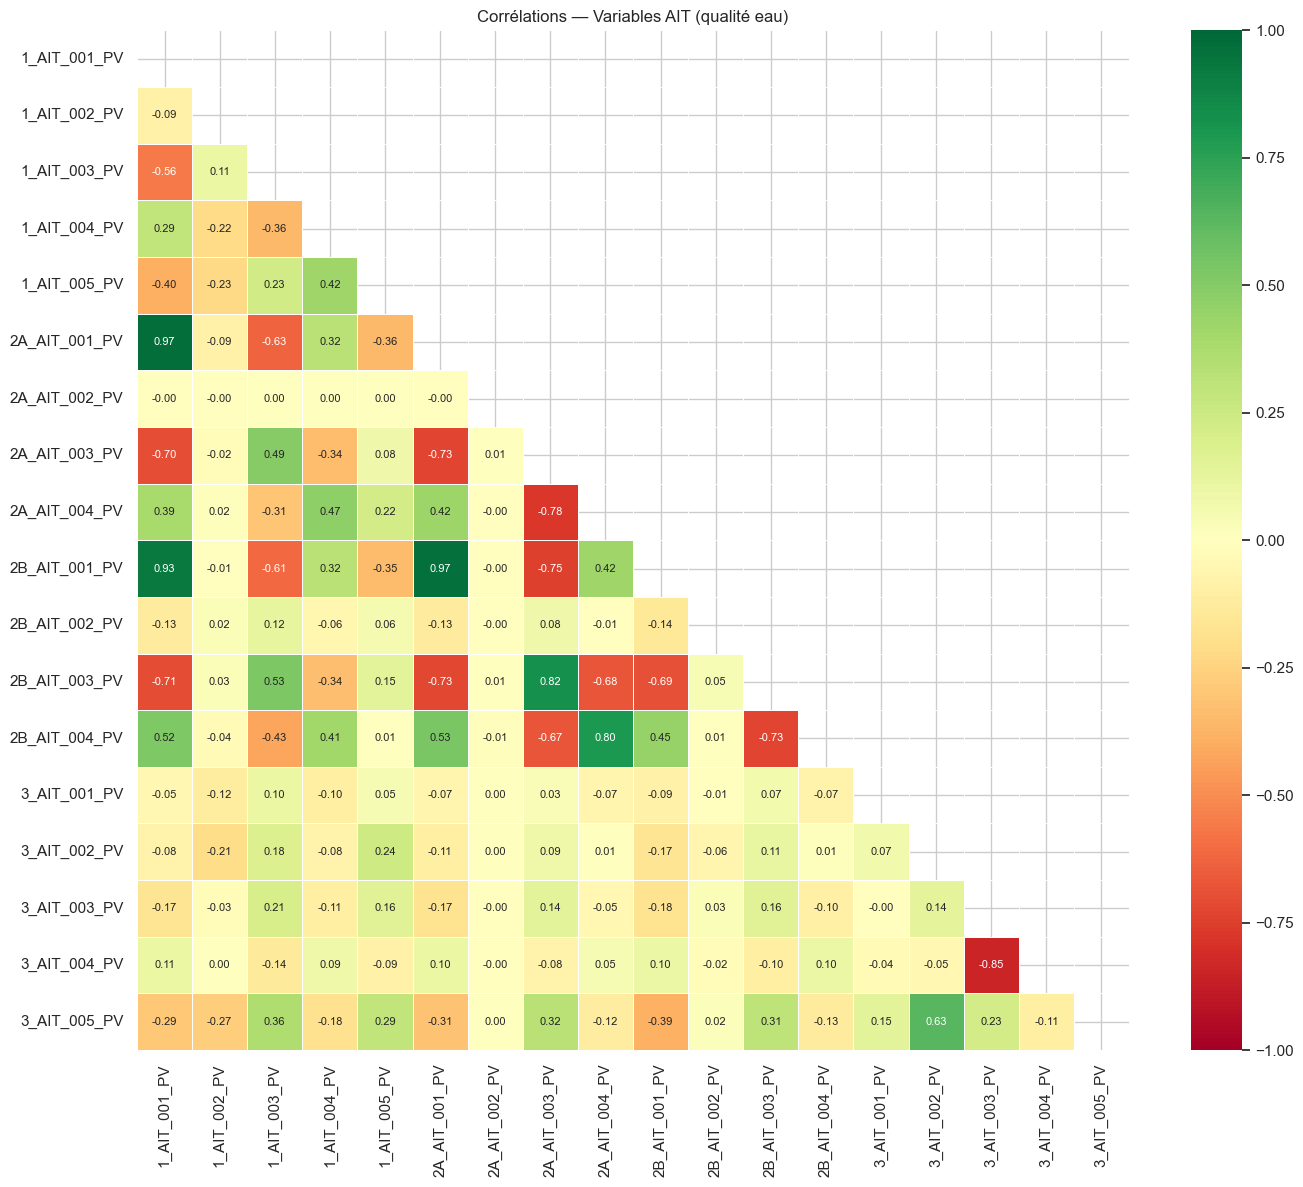

In [256]:
# ── Corrélation des capteurs AIT (qualité eau) ────────────────────────────────
plot_corr_matrix(df, 'AIT', 'Corrélations — Variables AIT (qualité eau)', figsize=(14, 12))

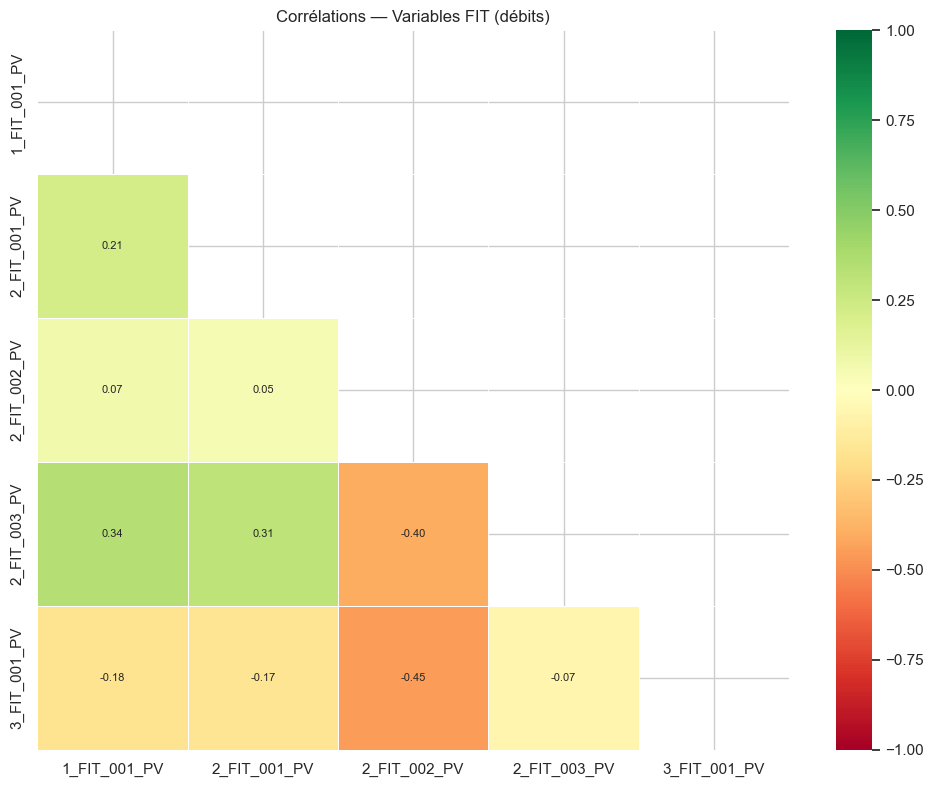

In [258]:
# ── Corrélation des débits FIT ────────────────────────────────────────────────
plot_corr_matrix(df, 'FIT', 'Corrélations — Variables FIT (débits)', figsize=(10, 8))

Top 20 variables les plus corrélées avec 3_LT_001_PV :
2_FIC_401_CO               0.6414
2_FIC_101_CO               0.5294
3_FIT_001_PV               0.4506
2_MCV_301_CO               0.4476
2_MCV_601_CO               0.4015
2_FIT_002_PV               0.3732
3_AIT_005_PV               0.3528
2_FQ_401_PV                0.3459
2_FIC_401_PV               0.3454
2_FIC_501_CO               0.3388
2_FIC_201_CO               0.3171
hour                       0.3051
TOTAL_CONS_REQUIRED_FLOW   0.3011
2_FIC_401_SP               0.2916
2_FIC_101_PV               0.2830
2_FQ_101_PV                0.2829
2_FIC_201_SP               0.2758
3_AIT_002_PV               0.2718
2_MCV_501_CO               0.2605
2_FIC_101_SP               0.2601


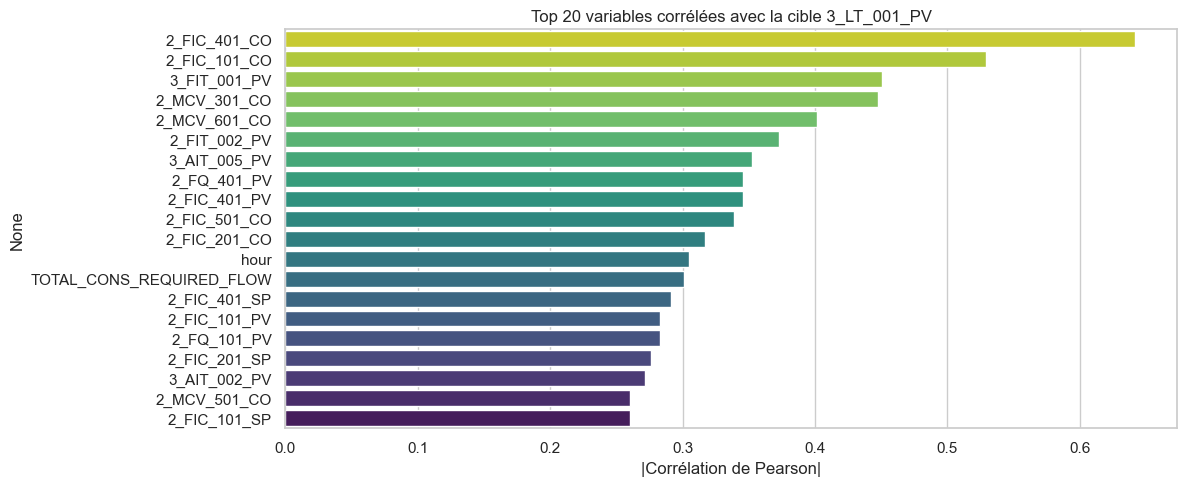

In [260]:
# ── Corrélations de TOUTES les variables numériques avec la cible ─────────────
corr_with_target = (
    df.select_dtypes(include='number')
      .corr()[TARGET]
      .drop(TARGET)
      .abs()
      .sort_values(ascending=False)
)

print(f'Top 20 variables les plus corrélées avec {TARGET} :')
print(corr_with_target.head(20).to_string())

# ── Barplot des top corrélations ──────────────────────────────────────────────
top20 = corr_with_target.head(20)
plt.figure(figsize=(12, 5))
sns.barplot(x=top20.values, y=top20.index, palette='viridis_r', orient='h')
plt.xlabel('|Corrélation de Pearson|')
plt.title(f'Top 20 variables corrélées avec la cible {TARGET}', fontsize=12)
plt.tight_layout()
plt.show()

<a id='11'></a>
## 11. Analyse en Composantes Principales (ACP)

L'ACP permet de réduire la dimensionnalité et de visualiser la structure globale du jeu de données.  
On exclut les variables cibles (LT) et on travaille uniquement sur les variables numériques continues.

In [262]:
# ── Préparation des données pour l'ACP ───────────────────────────────────────
lt_cols_all = [c for c in df.columns if 'LT' in c]

df_pca_input = (
    df.select_dtypes(include='number')
      .drop(columns=lt_cols_all + ['hour'], errors='ignore')
      .dropna()
)

# Sous-échantillonnage pour accélérer le calcul (1 ligne sur 10)
df_pca_sample = df_pca_input.iloc[::10]

print(f'Données pour ACP : {df_pca_sample.shape[0]:,} lignes × {df_pca_sample.shape[1]} colonnes')

Données pour ACP : 78,457 lignes × 63 colonnes


In [266]:
# ── Standardisation + ACP ────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_sample)

pca = PCA(n_components=20, random_state=42)
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print('Variance expliquée par composante :')
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f'  PC{i+1:2d} : {ev*100:5.2f}%   (cumulé : {cv*100:6.2f}%)')

Variance expliquée par composante :
  PC 1 : 23.05%   (cumulé :  23.05%)
  PC 2 : 13.83%   (cumulé :  36.89%)
  PC 3 :  9.07%   (cumulé :  45.96%)
  PC 4 :  7.47%   (cumulé :  53.43%)
  PC 5 :  5.00%   (cumulé :  58.43%)
  PC 6 :  3.32%   (cumulé :  61.75%)
  PC 7 :  3.04%   (cumulé :  64.78%)
  PC 8 :  2.81%   (cumulé :  67.59%)
  PC 9 :  2.30%   (cumulé :  69.89%)
  PC10 :  2.26%   (cumulé :  72.16%)
  PC11 :  2.21%   (cumulé :  74.37%)
  PC12 :  1.82%   (cumulé :  76.19%)
  PC13 :  1.65%   (cumulé :  77.84%)
  PC14 :  1.60%   (cumulé :  79.44%)
  PC15 :  1.59%   (cumulé :  81.02%)
  PC16 :  1.42%   (cumulé :  82.44%)
  PC17 :  1.40%   (cumulé :  83.85%)
  PC18 :  1.26%   (cumulé :  85.10%)
  PC19 :  1.15%   (cumulé :  86.25%)
  PC20 :  1.01%   (cumulé :  87.26%)


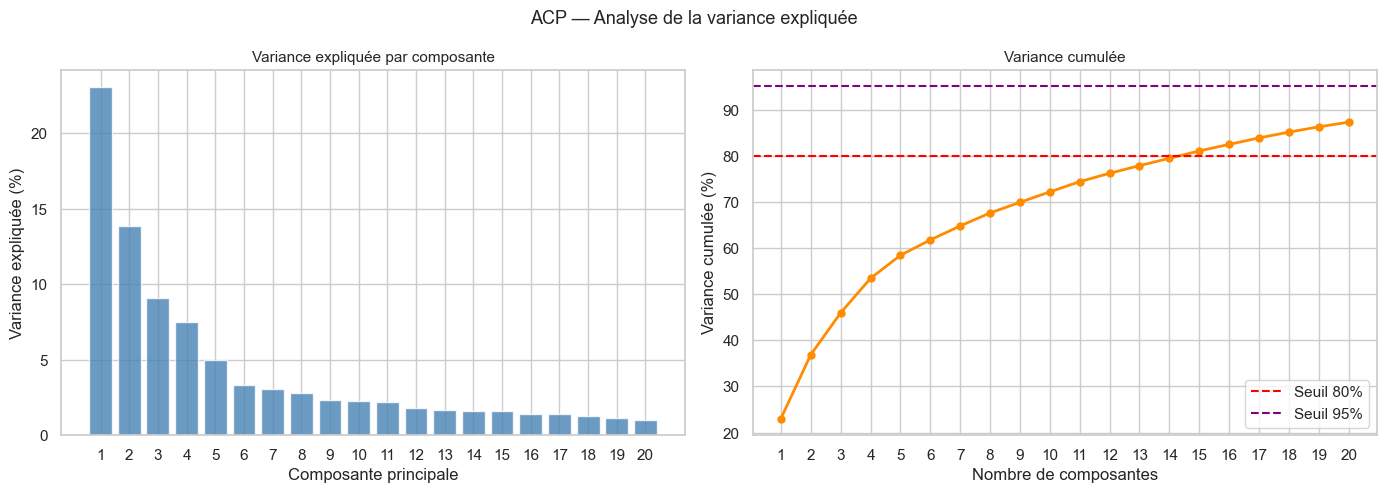

In [268]:
# ── Scree plot (éboulis) ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance par composante
axes[0].bar(range(1, 21), explained_var * 100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Variance expliquée par composante', fontsize=11)
axes[0].set_xticks(range(1, 21))

# Variance cumulée
axes[1].plot(range(1, 21), cumulative_var * 100,
             color='darkorange', linewidth=2, marker='o', markersize=5)
axes[1].axhline(80, color='red', linestyle='--', label='Seuil 80%')
axes[1].axhline(95, color='purple', linestyle='--', label='Seuil 95%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée', fontsize=11)
axes[1].set_xticks(range(1, 21))
axes[1].legend()

plt.suptitle('ACP — Analyse de la variance expliquée', fontsize=13)
plt.tight_layout()
plt.show()

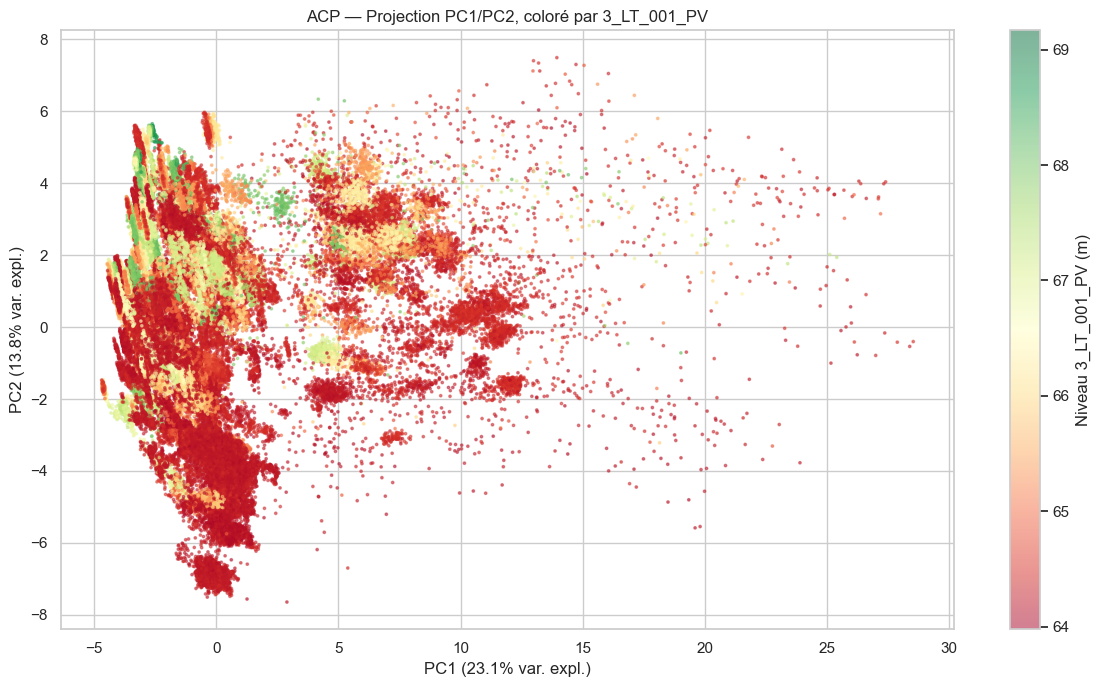

In [270]:
# ── Projection dans l'espace PC1 / PC2 (coloré par niveau cible) ─────────────
pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_scaled)

# Récupération du niveau cible aligné sur l'échantillon
target_vals = df[TARGET].reindex(df_pca_sample.index).values

plt.figure(figsize=(12, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1],
                 c=target_vals, cmap='RdYlGn', s=3, alpha=0.5)
plt.colorbar(sc, label=f'Niveau {TARGET} (m)')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% var. expl.)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% var. expl.)')
plt.title(f'ACP — Projection PC1/PC2, coloré par {TARGET}', fontsize=12)
plt.tight_layout()
plt.show()

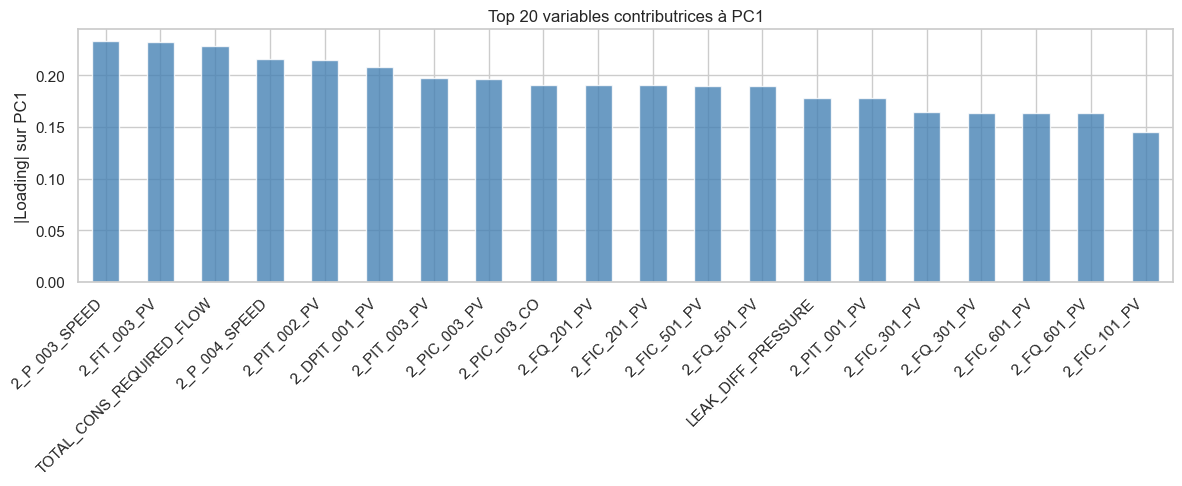

In [272]:
# ── Top contributeurs de PC1 ──────────────────────────────────────────────────
loadings = pd.Series(np.abs(pca2.components_[0]),
                     index=df_pca_sample.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
loadings.head(20).plot(kind='bar', color='steelblue', alpha=0.8)
plt.ylabel('|Loading| sur PC1')
plt.title('Top 20 variables contributrices à PC1', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a id='12'></a>
## 12. Sauvegarde du dataset nettoyé

On sauvegarde le dataset préprocessé pour l'utiliser directement dans les notebooks de modélisation.

In [ ]:
df_final = df.drop(columns=['hour', 'day'], errors='ignore')

In [274]:
# Suppression des colonnes auxiliaires créées pendant l'EDA
df_final = df.drop(columns=['hour', 'day'], errors='ignore')

OUTPUT_PATH = 'WADI_clean.csv'
df_final.to_csv(OUTPUT_PATH)

print(f' Dataset nettoyé sauvegardé : {OUTPUT_PATH}')
print(f'   Dimensions finales : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes')
print(f'   Variables cibles disponibles : {LT_COLS}')
print(f'   Variable cible principale    : {TARGET}')

 Dataset nettoyé sauvegardé : WADI_clean.csv
   Dimensions finales : 784,571 lignes × 121 colonnes
   Variables cibles disponibles : ['1_LT_001_PV', '2_LT_001_PV', '2_LT_002_PV', '3_LT_001_PV']
   Variable cible principale    : 3_LT_001_PV


---
## ✅ Synthèse EDA

| Étape | Résultat clé |
|---|---|
| Données brutes | 784 571 lignes × 130 colonnes, fréquence 1 min |
| Colonnes supprimées | Colonnes vides + colonnes constantes |
| Valeurs manquantes | Interpolation linéaire (limit=5) + ffill catégorielles |
| Variables cibles | 4 colonnes LT — cible principale : `3_LT_001_PV` |
| Outliers | Détectés par IQR — conservés (événements industriels réels) |
| Corrélations | Top variables corrélées à la cible identifiées |
| ACP | Structure basse dimension capturée — prête pour feature selection |

**Prochaines étapes :**  
→ Feature engineering (lags, rolling stats)  
→ Modélisation baseline (persistence, XGBoost)  
→ Modèles deep learning (LSTM/GRU)